### Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

import sys, os
sys.path.append(os.path.join(os.getcwd(), ".."))

from ml_force.models import MorrisLecar, MorrisLecarCurrent, z_transform

In [3]:
T = 10000
dt = 5e-2
t = np.arange(0, T, dt)

### Run Models

#### Preparing functions

In [4]:
from ml_force import VanDerPol, LorenzAttractor

# x = VanDerPol(T, dt, mu=.5, tau=0.015).generate(transient_time=200)
x = LorenzAttractor(T, dt, tau=0.015).generate(transient_time=500)
x = x.T
# x = np.sin(2 * 10 * np.pi * t / 1000)
# x = x.reshape(-1, 1)

x = z_transform(x)
print(x.shape)

(200000, 3)


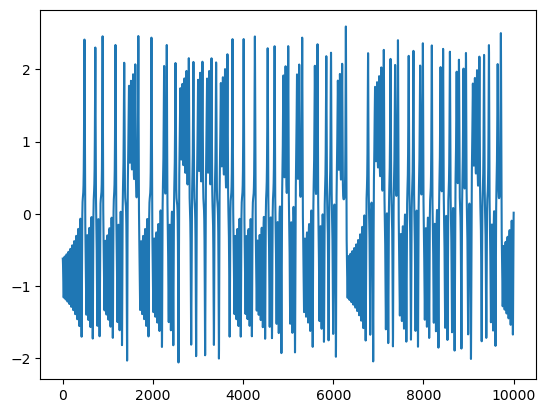

In [5]:
plt.plot(t, x[:, 0])
plt.show()

#### Run Current-Based Model model

In [10]:
## TORCH SETUP
seed = 2024
np.random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)

Using Device <cuda> for PyTorch computations...



In [17]:
N = 1000
# input current for I and E neurons
Ie = 75
Ii = 75
current = np.ones((N, 1))
middle = N // 2
current[:middle] *= Ie  # NE bias
current[middle:] *= Ii  # NI bias

p = .1

# x = np.zeros(shape=x.shape, dtype=float)
block = MorrisLecarCurrent(supervisor=x, T=T, dt=dt, N=N, BIAS=current, gbar=100, Q=0, l=1e-5, device=device, p_sparsity=p)

In [18]:
block.w /= torch.linalg.eigvalsh(block.w).abs().max() * 1.2

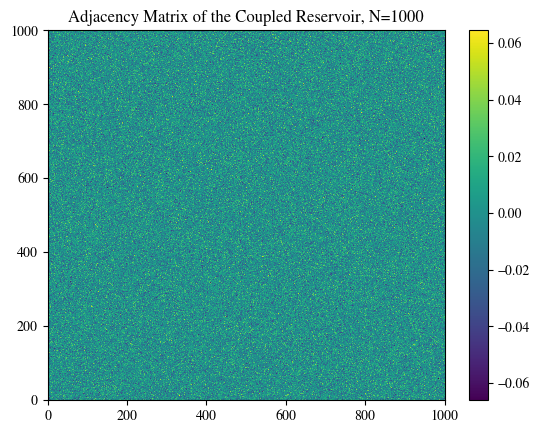

In [19]:
clr = plt.pcolormesh(block.w.cpu().numpy(), cmap="viridis")
plt.colorbar(clr)
plt.title(f"Adjacency Matrix of the Coupled Reservoir, N={block._N}")
plt.savefig("img/weight_matrix.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
print("mean abs:", block.w.abs().mean())
print("std:", block.w.std())
print("mean:", block.w.mean())

mean abs: tensor(0.0106, device='cuda:0', dtype=torch.float64)
std: tensor(0.0132, device='cuda:0', dtype=torch.float64)
mean: tensor(-1.1124e-06, device='cuda:0', dtype=torch.float64)


In [21]:
rls_start = 500
rls_stop = 7000
rls_stop = -1
rls_step = 20

render_params = {"rls_start": rls_start,
                    "rls_stop": rls_stop,
                    "rls_step": rls_step,
                    "live_plot": False,
                    "n_neurons": 10,
                    "plt_interval": 300,
                    "save_all": False}

_, voltage_trace, decoder_trace = block.render(**render_params)

100%|██████████| 200000/200000 [06:27<00:00, 515.71it/s] 


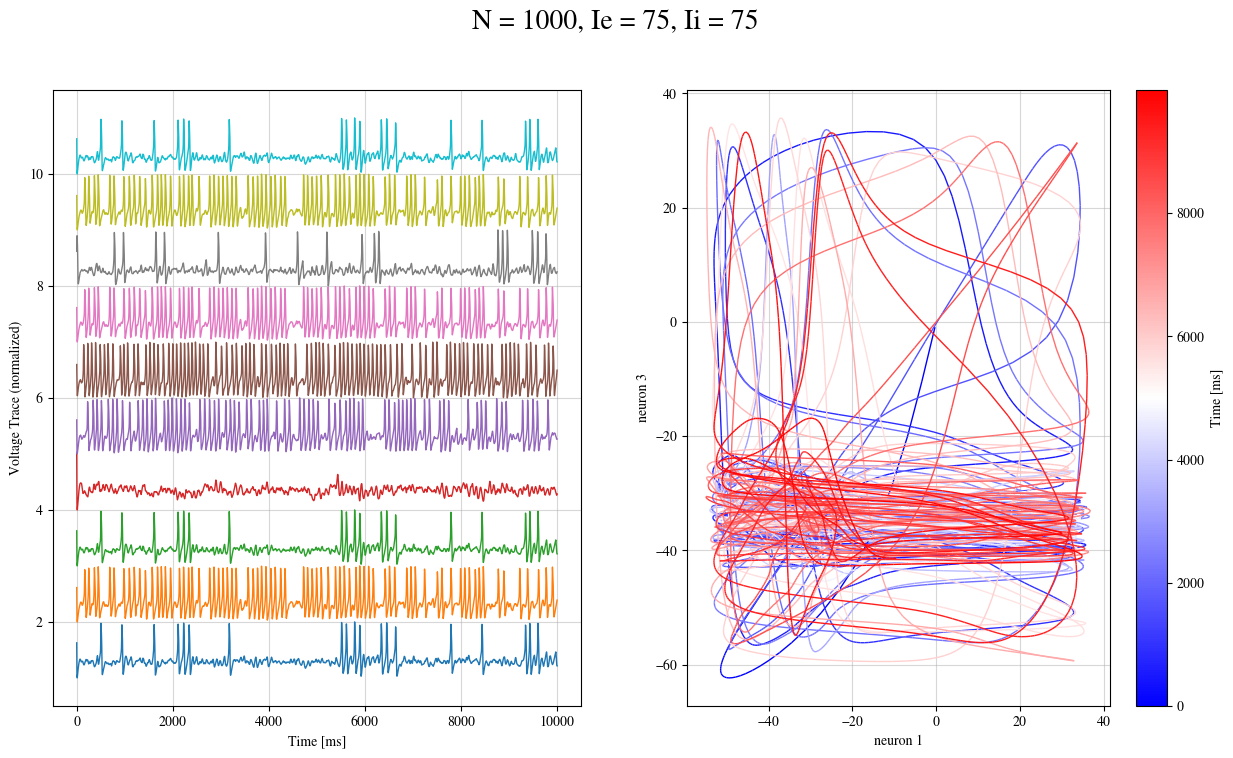

In [22]:
import matplotlib as mpl
mpl.rcParams["font.family"] = "Nimbus Roman"
from matplotlib.collections import LineCollection

voltage_trace_np = voltage_trace.numpy()
rands = np.random.randint(low=0, high=10, size=10)

step = 10

fig, ax = plt.subplots(figsize=(15, 8), ncols=2)
# Ax 0
for i, num in enumerate(rands):
    signal = voltage_trace_np[::step, num]
    minim = np.nanmin(signal)
    maxim = np.nanmax(signal)
    signal = (signal - minim) / (maxim - minim) + i+1
    ax[0].plot(t[::step], signal, lw=1)
ax[0].grid(alpha=.5)
ax[0].set_xlabel("Time [ms]")
ax[0].set_ylabel("Voltage Trace (normalized)")
# Ax 1
shift = 5
midpoint = block._N // 2
# e_ind = shift
# i_ind = midpoint + shift
e_ind = 1
i_ind = 3
start = 0
ve_store = voltage_trace_np[start::step, e_ind]
vi_store = voltage_trace_np[start::step, i_ind]
points = np.array([ve_store, vi_store]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = mpl.colors.Normalize(vmin=t.min(), vmax=t.max())
lc = LineCollection(segments, norm=norm, cmap='bwr', linewidth=1)
lc.set_array(t[start::step])
ax[1].add_collection(lc)
ax[1].autoscale()
# ax[1].plot(ve_store, vi_store, lw=.5, norm=norm, cmap='inferno')
ax[1].grid(alpha=.5)
ax[1].set_xlabel(f"neuron {e_ind}")
ax[1].set_ylabel(f"neuron {i_ind}")
cbar = plt.colorbar(lc)
cbar.set_label('Time [ms]')

plt.suptitle(f"N = {block._N}, Ie = {Ie}, Ii = {Ii}", fontsize=20)
plt.savefig("img/initial_chaos_voltage_trace2.jpg", dpi=300, bbox_inches='tight')
plt.show()

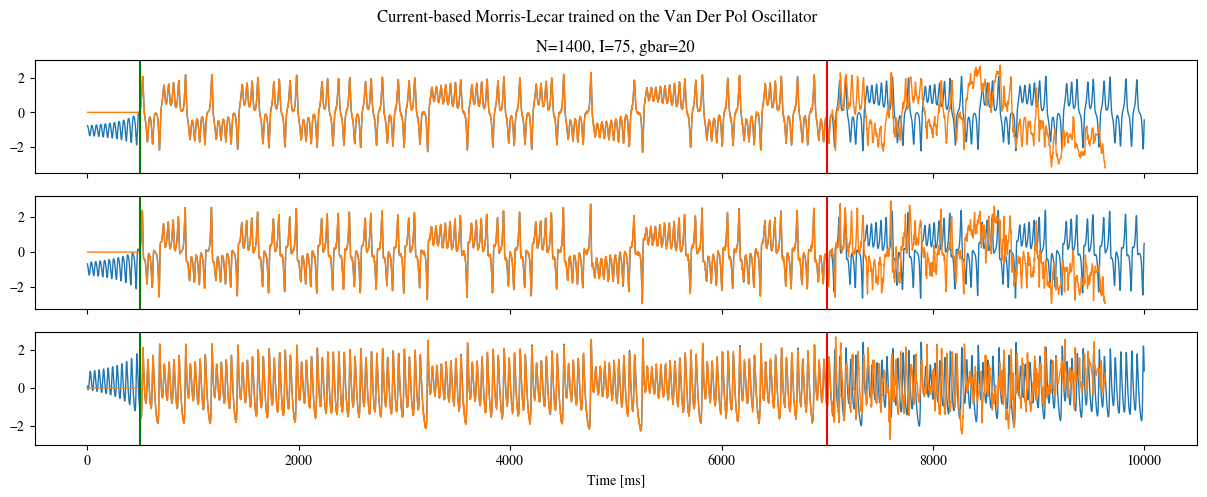

In [64]:

test_index = int(rls_stop // dt) 
xhat = block.x_hat_rec.cpu().numpy()
sup = x[test_index:]

t_test = t[test_index:]

nrows = sup.shape[1]
fig, ax = plt.subplots(figsize=(15, 5), nrows=nrows, sharex=True)

for i in range(nrows):
    ax[i].plot(t, x[:, i], lw=1)
    ax[i].plot(t, xhat[:, i], lw=1)

    ax[i].axvline(x=rls_start, c='g')
    ax[i].axvline(x=rls_stop, c='red')

plt.suptitle("Current-based Morris-Lecar trained on the Van Der Pol Oscillator")
ax[0].set_title(f"N={block._N}, I={Ie}, gbar={block.gbar}")
plt.xlabel('Time [ms]')
plt.savefig("img/lorenz_current_output.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from ml_force import plot_model

plot_model(block, "lorenz_current", _, voltage_trace, decoder_trace, rls_start, rls_stop, rls_step, block.l, 30, )

In [56]:
from ml_force import plot_model


plot_model(block, 'lorenz_current', _, voltage_trace, decoder_trace, 
           rls_start, rls_stop, rls_step,
           lamda=block.l, Q=200, n_vars=3, mode='vertical')


(1000000,)


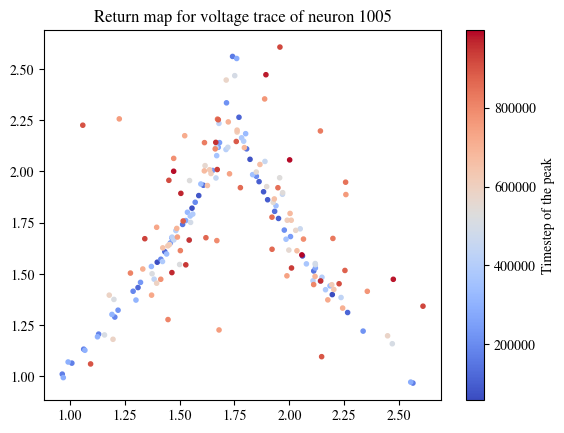

In [39]:
from scipy.signal import find_peaks


# Return Map
signal = xhat[:, 2]

print(signal.shape)
# signal = z_transform(signal)
peaks = find_peaks(signal, distance=2000)[0]
peaks_filtered = peaks[np.where(signal[peaks] > 0)[0]]

clr = plt.scatter(signal[peaks_filtered[:-1]], signal[peaks_filtered[1:]], c=peaks_filtered[1:], cmap="coolwarm", marker='.')
plt.colorbar(clr, label="Timestep of the peak")
plt.title(f"Return map for voltage trace of neuron {i_ind}")
# plt.savefig("img/initial_chaos_return_map_inh.jpg", dpi=300, bbox_inches="tight")
plt.show()


(99000,)


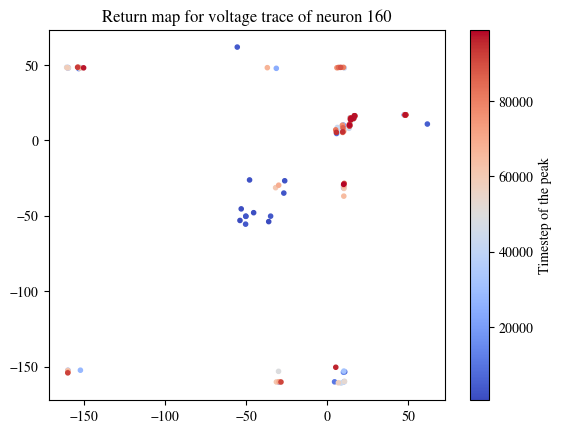

In [124]:
from scipy.signal import find_peaks


# Return Map
signal = ve_store
print(signal.shape)
# signal = z_transform(signal)
peaks = find_peaks(signal)[0]

clr = plt.scatter(signal[peaks[:-1]], signal[peaks[1:]], c=peaks[1:], cmap="coolwarm", marker='.')
plt.colorbar(clr, label="Timestep of the peak")
plt.title(f"Return map for voltage trace of neuron {e_ind}")
# plt.savefig("img/initial_chaos_return_map_exc.jpg", dpi=300, bbox_inches="tight")
plt.show()
